# CH3CN experimental gas-phase IR spectrum from NIST

This notebook redraws the acetonitrile gas-phase IR spectrum from the NIST Chemistry WebBook JCAMP-DX data file. The downloaded JCAMP data are reported as transmittance, so the plot converts them to absorbance with `absorbance = -log10(transmittance)`.

Source: https://webbook.nist.gov/cgi/cbook.cgi?ID=C75058&Type=IR-SPEC&Index=1#IR-SPEC


In [1]:
from pathlib import Path
import re
import ssl
import urllib.request

import numpy as np
import matplotlib.pyplot as plt


In [2]:
WORK_DIR = Path('/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev')
NIST_IR_JCAMP_URL = 'https://webbook.nist.gov/cgi/cbook.cgi?Index=1&JCAMP=C75058&Type=IR'
JDX_PATH = WORK_DIR / 'CH3CN_NIST_experimental_IR_spectrum.jdx'
CSV_PATH = WORK_DIR / 'CH3CN_NIST_experimental_IR_spectrum.csv'
PDF_PATH = WORK_DIR / 'CH3CN_NIST_experimental_IR_spectrum.pdf'
PNG_PATH = WORK_DIR / 'CH3CN_NIST_experimental_IR_spectrum.png'

# The notebook reads the local file first. If it is missing, it downloads it from NIST.
if not JDX_PATH.exists():
    try:
        jcamp_bytes = urllib.request.urlopen(NIST_IR_JCAMP_URL, timeout=30).read()
    except Exception:
        ssl_context = ssl._create_unverified_context()
        jcamp_bytes = urllib.request.urlopen(NIST_IR_JCAMP_URL, context=ssl_context, timeout=30).read()
    JDX_PATH.write_bytes(jcamp_bytes)


In [3]:
def parse_jcamp_xydata(path):
    lines = path.read_text(errors='replace').splitlines()
    metadata = {}
    in_xy = False
    xy_lines = []

    for line in lines:
        s = line.strip()
        if not s:
            continue
        if s.startswith('##'):
            if in_xy:
                break
            if '=' in s:
                key, value = s[2:].split('=', 1)
                metadata[key.strip().upper()] = value.strip()
            if s.upper().startswith('##XYDATA='):
                in_xy = True
            continue
        if in_xy:
            xy_lines.append(s)

    def meta_float(key, default=1.0):
        value = metadata.get(key)
        if value is None:
            return default
        return float(value.split()[0])

    first_x = meta_float('FIRSTX')
    last_x = meta_float('LASTX')
    npoints = int(round(meta_float('NPOINTS')))
    xfactor = meta_float('XFACTOR', 1.0)
    yfactor = meta_float('YFACTOR', 1.0)
    delta_x = meta_float('DELTAX', (last_x - first_x) / (npoints - 1))

    x_values = []
    y_values = []
    number_re = re.compile(r'[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[Ee][-+]?\d+)?')
    for row in xy_lines:
        nums = [float(token) for token in number_re.findall(row)]
        if len(nums) < 2:
            continue
        row_x = nums[0] * xfactor
        row_y = [y * yfactor for y in nums[1:]]
        for offset, y in enumerate(row_y):
            x_values.append(row_x + offset * delta_x * xfactor)
            y_values.append(y)

    x_values = np.asarray(x_values[:npoints], dtype=float)
    y_values = np.asarray(y_values[:npoints], dtype=float)
    return x_values, y_values, metadata

wavenumber, transmittance, metadata = parse_jcamp_xydata(JDX_PATH)
absorbance = -np.log10(np.clip(transmittance, 1e-12, None))

np.savetxt(
    CSV_PATH,
    np.column_stack([wavenumber, transmittance, absorbance]),
    delimiter=',',
    header='wavenumber_cm_minus_1,transmittance,absorbance',
    comments='',
)

print(f'Loaded {len(wavenumber)} points from {JDX_PATH.name}')
print(f'Wavenumber range: {wavenumber.min():.0f}-{wavenumber.max():.0f} cm^-1')
print(f'Y data in JCAMP: {metadata.get("YUNITS", "unknown")} -> plotted as absorbance = -log10(transmittance)')
print(f'Saved CSV: {CSV_PATH}')


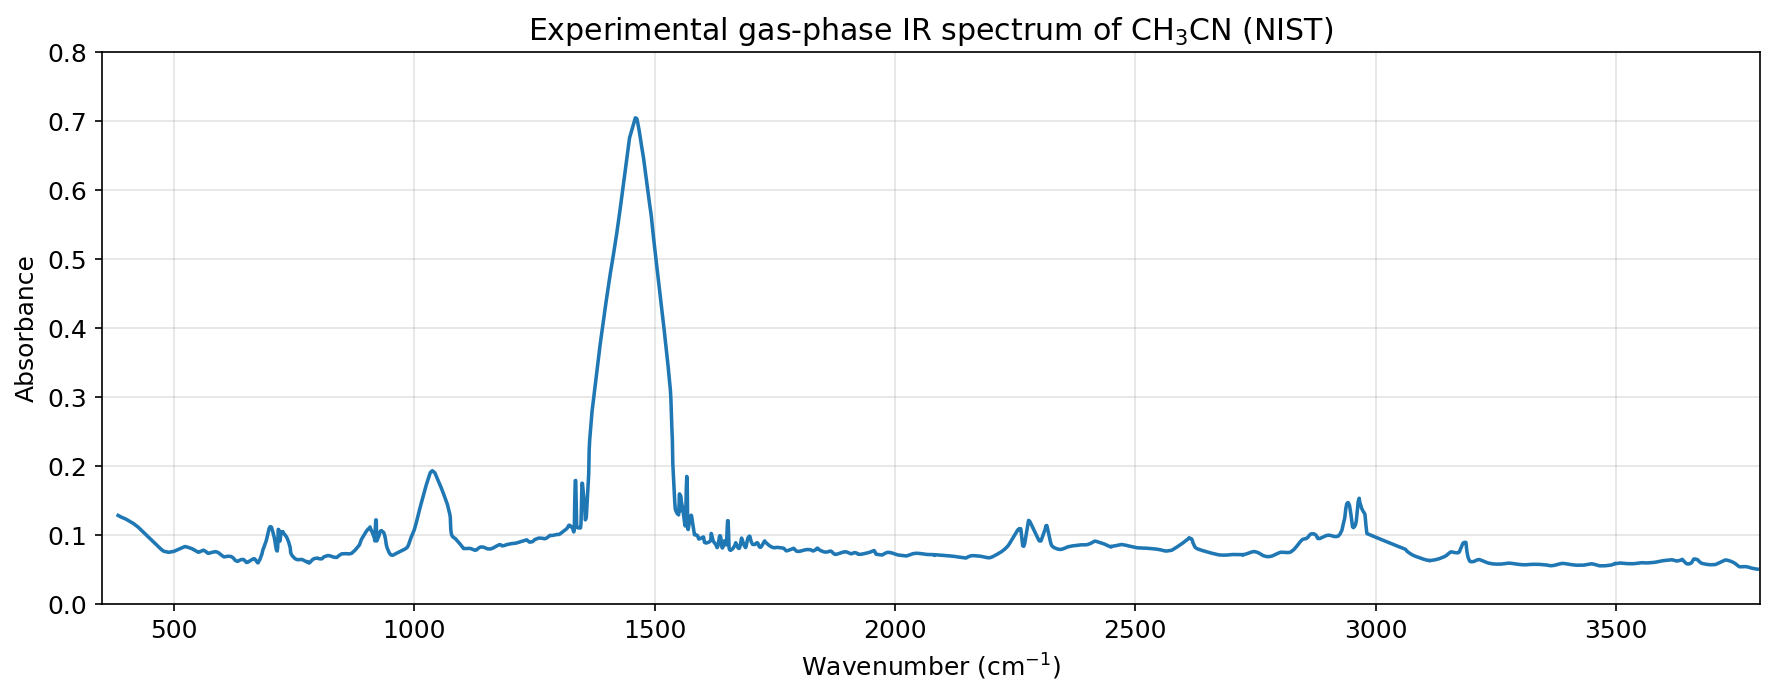

Saved PDF: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_NIST_experimental_IR_spectrum.pdf\n
Saved PNG: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_NIST_experimental_IR_spectrum.png\n

In [4]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(wavenumber, absorbance, color='#1f77b4', lw=1.7)
ax.set_title(r'Experimental gas-phase IR spectrum of CH$_3$CN (NIST)')
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Absorbance')
ax.set_xlim(350, 3800)
ax.set_ylim(0, max(0.8, float(np.nanmax(absorbance)) * 1.08))
ax.grid(True, alpha=0.35)
fig.tight_layout()
fig.savefig(PDF_PATH, bbox_inches='tight')
fig.savefig(PNG_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved PDF: {PDF_PATH}')
print(f'Saved PNG: {PNG_PATH}')


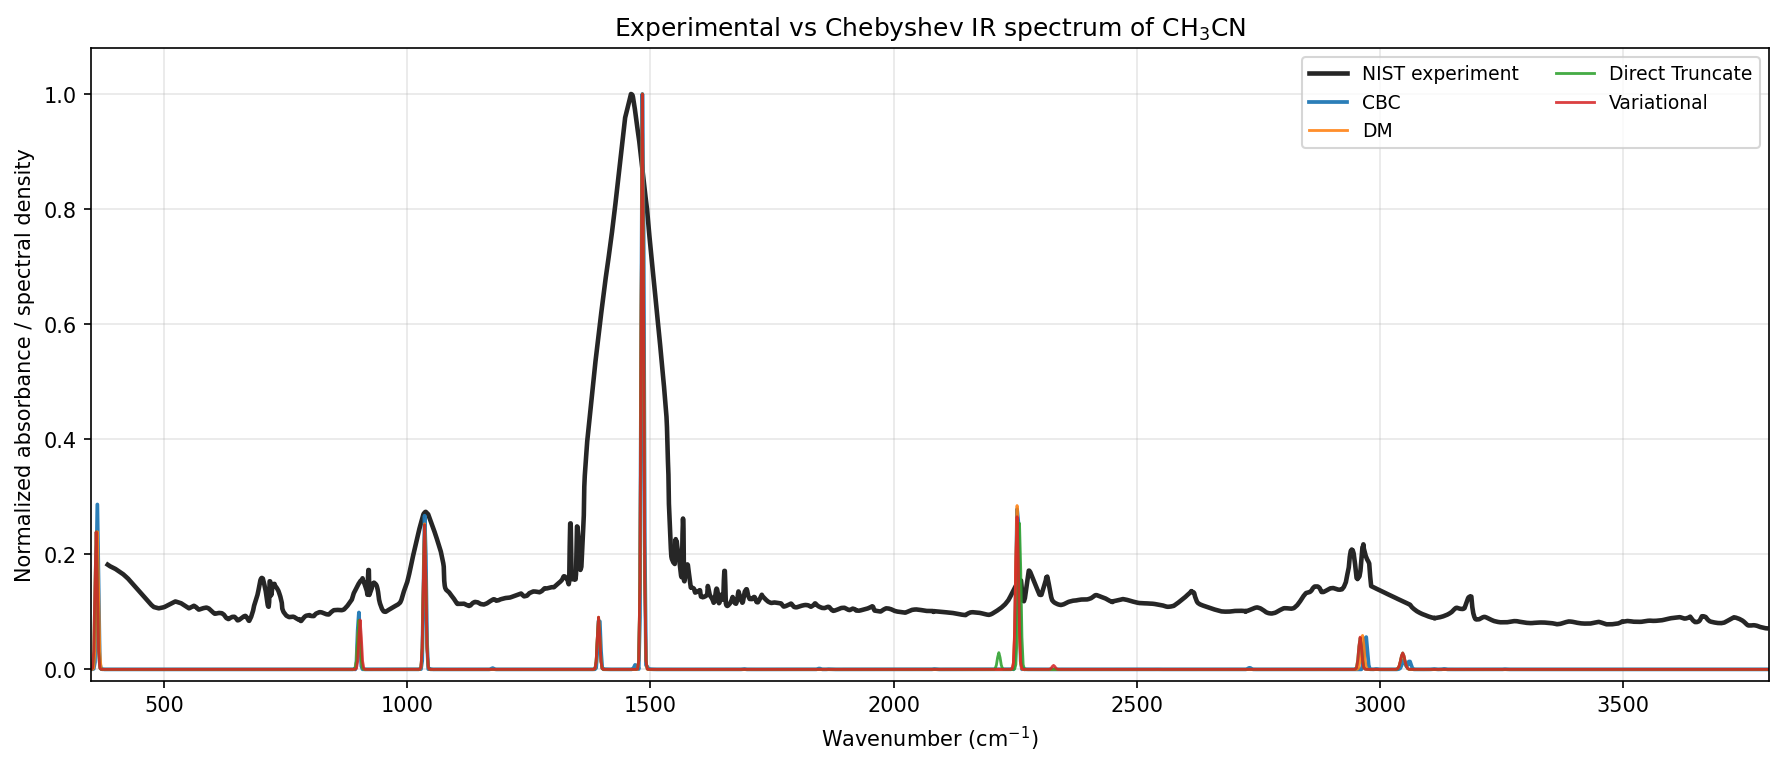

Saved theory CSV: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_14dim_200N_mu0_summed_spectral_density_for_NIST_comparison.csv
Saved comparison PDF: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_NIST_vs_T3NS_14dim_200N_spectrum_comparison.pdf
Saved comparison PNG: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_NIST_vs_T3NS_14dim_200N_spectrum_comparison.png


In [5]:
# --- NIST_VS_T3NS_COMPARISON_START ---
# Overlay the NIST experimental absorbance with the CH3CN_T3NS_14dim_200N_mu0 spectrum.
# CBC is loaded from the saved CBC_result array. The other three methods are reconstructed
# from the saved peak positions/heights/areas printed in CH3CN_T3NS_14dim_200N_mu0.ipynb,
# so this cell does not rerun any Chebyshev/TTNS calculation.
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

WORK_DIR = Path('/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev')
NIST_CSV_PATH = WORK_DIR / 'CH3CN_NIST_experimental_IR_spectrum.csv'
CBC_NPZ_PATH = WORK_DIR / 'CBC_result' / 'chebyshev_spectrum_data.npz'
THEORY_CSV_PATH = WORK_DIR / 'CH3CN_T3NS_14dim_200N_mu0_summed_spectral_density_for_NIST_comparison.csv'
COMPARISON_PDF_PATH = WORK_DIR / 'CH3CN_NIST_vs_T3NS_14dim_200N_spectrum_comparison.pdf'
COMPARISON_PNG_PATH = WORK_DIR / 'CH3CN_NIST_vs_T3NS_14dim_200N_spectrum_comparison.png'

PEAK_ROWS_BY_METHOD = {'DM': [{'peak_E': 0.362727, 'height': 0.016202, 'grid_area': 0.000100485}, {'peak_E': 0.900563, 'height': 0.00567582, 'grid_area': 3.87618e-05}, {'peak_E': 1.03565, 'height': 0.0171215, 'grid_area': 0.000108961}, {'peak_E': 1.39337, 'height': 0.00612711, 'grid_area': 3.93577e-05}, {'peak_E': 1.48343, 'height': 0.0677006, 'grid_area': 0.000439298}, {'peak_E': 2.25391, 'height': 0.0192779, 'grid_area': 0.000137524}, {'peak_E': 2.96435, 'height': 0.0039946, 'grid_area': 3.1835e-05}, {'peak_E': 3.0469, 'height': 0.00170047, 'grid_area': 1.85643e-05}], 'Direct Truncate': [{'peak_E': 0.360225, 'height': 0.0161625, 'grid_area': 0.00010048}, {'peak_E': 0.900563, 'height': 0.00578818, 'grid_area': 3.87585e-05}, {'peak_E': 1.03565, 'height': 0.0169619, 'grid_area': 0.00010894}, {'peak_E': 1.39337, 'height': 0.00609256, 'grid_area': 3.93204e-05}, {'peak_E': 1.48343, 'height': 0.0676277, 'grid_area': 0.000439176}, {'peak_E': 2.21639, 'height': 0.00196453, 'grid_area': 1.50252e-05}, {'peak_E': 2.25891, 'height': 0.0171648, 'grid_area': 0.00012358}, {'peak_E': 2.95935, 'height': 0.003667, 'grid_area': 2.98268e-05}, {'peak_E': 3.0469, 'height': 0.0019278, 'grid_area': 1.97013e-05}], 'Variational': [{'peak_E': 0.360225, 'height': 0.0161579, 'grid_area': 0.00010048}, {'peak_E': 0.903064, 'height': 0.00580575, 'grid_area': 3.87658e-05}, {'peak_E': 1.03565, 'height': 0.0169885, 'grid_area': 0.00010897}, {'peak_E': 1.39337, 'height': 0.00614492, 'grid_area': 3.93615e-05}, {'peak_E': 1.48343, 'height': 0.0676584, 'grid_area': 0.000438423}, {'peak_E': 2.25391, 'height': 0.0179459, 'grid_area': 0.000135623}, {'peak_E': 2.32896, 'height': 0.000468688, 'grid_area': 3.67144e-06}, {'peak_E': 2.95935, 'height': 0.00379424, 'grid_area': 2.9259e-05}, {'peak_E': 3.0469, 'height': 0.00193316, 'grid_area': 2.02303e-05}]}

def gaussian_spectrum_from_peak_rows(energy_grid_1000_cm, rows):
    spectrum = np.zeros_like(energy_grid_1000_cm, dtype=float)
    for row in rows:
        center = float(row['peak_E'])
        height = float(row['height'])
        area = float(row['grid_area'])
        if height <= 0 or area <= 0:
            continue
        sigma = area / (height * np.sqrt(2.0 * np.pi))
        sigma = max(sigma, 0.001)
        spectrum += height * np.exp(-0.5 * ((energy_grid_1000_cm - center) / sigma) ** 2)
    return spectrum

nist_data = np.genfromtxt(NIST_CSV_PATH, delimiter=',', names=True)
nist_wavenumber = np.asarray(nist_data['wavenumber_cm_minus_1'], dtype=float)
nist_absorbance = np.asarray(nist_data['absorbance'], dtype=float)

cbc_arrays = np.load(CBC_NPZ_PATH, allow_pickle=True)
theory_energy_1000_cm = np.asarray(cbc_arrays['E_grid'], dtype=float)
theory_wavenumber = 1000.0 * theory_energy_1000_cm
cbc_spectrum = np.asarray(cbc_arrays['cbc_vals_ttns_eff'], dtype=float)

theory_spectra = {
    'CBC': cbc_spectrum,
    'DM': gaussian_spectrum_from_peak_rows(theory_energy_1000_cm, PEAK_ROWS_BY_METHOD['DM']),
    'Direct Truncate': gaussian_spectrum_from_peak_rows(theory_energy_1000_cm, PEAK_ROWS_BY_METHOD['Direct Truncate']),
    'Variational': gaussian_spectrum_from_peak_rows(theory_energy_1000_cm, PEAK_ROWS_BY_METHOD['Variational']),
}

np.savetxt(
    THEORY_CSV_PATH,
    np.column_stack([
        theory_wavenumber,
        theory_spectra['CBC'],
        theory_spectra['DM'],
        theory_spectra['Direct Truncate'],
        theory_spectra['Variational'],
    ]),
    delimiter=',',
    header='wavenumber_cm_minus_1,CBC,DM,Direct_Truncate,Variational',
    comments='',
)

colors = {
    'NIST experiment': '0.15',
    'CBC': 'tab:blue',
    'DM': 'tab:orange',
    'Direct Truncate': 'tab:green',
    'Variational': 'tab:red',
}

fig, ax = plt.subplots(figsize=(12, 5.2))
nist_norm = nist_absorbance / np.nanmax(nist_absorbance)
ax.plot(nist_wavenumber, nist_norm, color=colors['NIST experiment'], lw=2.2, label='NIST experiment')

for label, spectrum in theory_spectra.items():
    spectrum = np.asarray(spectrum, dtype=float)
    max_val = np.nanmax(spectrum)
    if not np.isfinite(max_val) or max_val <= 0:
        continue
    ax.plot(
        theory_wavenumber,
        spectrum / max_val,
        lw=1.35 if label != 'CBC' else 1.8,
        alpha=0.88 if label != 'CBC' else 0.95,
        label=label,
        color=colors[label],
    )

ax.set_title(r'Experimental vs Chebyshev IR spectrum of CH$_3$CN')
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Normalized absorbance / spectral density')
ax.set_xlim(350, 3800)
ax.set_ylim(-0.02, 1.08)
ax.grid(True, alpha=0.30)
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(COMPARISON_PDF_PATH, bbox_inches='tight')
fig.savefig(COMPARISON_PNG_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved theory CSV: {THEORY_CSV_PATH}')
print(f'Saved comparison PDF: {COMPARISON_PDF_PATH}')
print(f'Saved comparison PNG: {COMPARISON_PNG_PATH}')
# --- NIST_VS_T3NS_COMPARISON_END ---
